# 003 Thinking in LangGraph

这是 LangGraph 学习线的第三份 Notebook。

官方参考：

- https://docs.langchain.com/oss/python/langgraph/thinking-in-langgraph

学习目标：

1. 理解 Thinking in LangGraph 是设计方法，不只是 API 教程
2. 学会把业务流程拆成 node
3. 学会区分 LLM node、data node、action node、human input node
4. 学会设计只保存原始数据和关键决策的 state
5. 用 `Command(update=..., goto=...)` 跑通一个客服邮件 workflow

这一讲不调用真实模型，用确定性 Python 节点模拟官方思路。

## 1. 这节课解决什么问题

前两讲已经能写出图：

```text
START -> node -> node -> END
```

但真实业务里，更难的是：

```text
这个任务到底该拆成哪些节点？
哪些节点应该调用模型？
哪些节点只是查数据？
哪些节点要执行副作用？
哪些地方需要人类介入？
state 里到底该保存什么？
```

Thinking in LangGraph 关注的就是这些设计问题。

## 2. 设计 LangGraph 的四步

可以按这个顺序思考：

1. **拆流程**：把业务过程拆成稳定步骤
2. **分节点类型**：判断每一步是 LLM、data、action 还是 human input
3. **设计 state**：只保存原始输入、关键决策和下游真正需要的数据
4. **连边**：固定边用 `add_edge`，动态边用 `Command` 或 conditional edge

不要一上来就问“该用几个 agent”。

应该先问：

```text
这个任务有哪些稳定步骤？
这些步骤之间如何传递状态？
```

In [56]:
from typing import Literal, TypedDict

from langgraph.graph import END, START, StateGraph
from langgraph.types import Command


## 3. 示例业务：客服邮件 workflow

我们模拟一个客服邮件处理流程：

```text
read_email
  -> classify_intent
    -> search_documentation
    -> bug_tracking
    -> human_review
  -> draft_response
  -> send_reply
```

节点类型可以这样分：

| 节点 | 类型 | 职责 |
| --- | --- | --- |
| `read_email` | data node | 读取并整理邮件输入 |
| `classify_intent` | LLM node | 判断意图、紧急程度和主题 |
| `search_documentation` | data node | 查知识库 |
| `bug_tracking` | action/data node | 创建或查询 bug ticket |
| `human_review` | human input node | 人类审核高风险情况 |
| `draft_response` | LLM node | 起草回复 |
| `send_reply` | action node | 发送或记录最终回复 |

## 4. 设计 State

State 不应该保存所有中间想法。

它应该保存后续节点真正需要的数据。

这个例子里保存：

- 原始邮件
- 发件人
- 分类结果
- 文档搜索结果
- bug ticket
- 草稿回复
- 最终动作
- trace，用来教学观察流程

In [57]:
class EmailClassification(TypedDict):
    intent: str
    urgency: str
    topic: str
    summary: str


class EmailAgentState(TypedDict):
    email_content: str
    sender_email: str
    classification: EmailClassification | None
    search_results: list[str]
    ticket_id: str
    draft_response: str
    final_action: str
    trace: list[str]


def add_trace(state: EmailAgentState, step: str) -> list[str]:
    return [*state.get("trace", []), step]


## 5. Data node：read_email

`read_email` 不需要模型。

它只是确认输入已经进入 workflow，并记录 trace。

In [58]:
def read_email(state: EmailAgentState) -> dict:
    return {
        "trace": add_trace(state, "read_email"),
    }


## 6. LLM node：classify_intent

真实系统里，这一步通常会调用模型做结构化分类。

本课为了稳定运行，用关键词模拟分类结果。

`classify_intent` 返回 `Command`：

```python
Command(update={...}, goto="next_node")
```

这表示：

```text
既更新 state，又决定下一步去哪。
```

In [59]:
def classify_intent(
    state: EmailAgentState,
) -> Command[Literal["search_documentation", "bug_tracking", "human_review"]]:
    content = state["email_content"].lower()

    if any(word in content for word in ["crash", "bug", "500", "error"]):
        classification = {
            "intent": "bug_report",
            "urgency": "high",
            "topic": "product_error",
            "summary": "用户报告产品错误，需要进入 bug 流程。",
        }
        goto = "bug_tracking"
    elif any(word in content for word in ["charged", "invoice", "billing", "扣费", "账单"]):
        classification = {
            "intent": "billing_issue",
            "urgency": "critical",
            "topic": "billing",
            "summary": "用户反馈账单或扣费问题，需要人工审核。",
        }
        goto = "human_review"
    else:
        classification = {
            "intent": "product_question",
            "urgency": "low",
            "topic": "how_to",
            "summary": "用户咨询产品使用问题，可以先查文档。",
        }
        goto = "search_documentation"

    return Command(
        update={
            "classification": classification,
            "trace": add_trace(state, "classify_intent:" + goto),
        },
        goto=goto,
    )


## 7. Data / Action nodes

下面三个节点分别代表：

- 查文档
- 处理 bug ticket
- 人工审核

真实系统里这些节点可能会访问数据库、搜索系统、工单系统或人工审批队列。

In [60]:
def search_documentation(state: EmailAgentState) -> Command[Literal["draft_response"]]:
    return Command(
        update={
            "search_results": [
                "帮助文档：可以在账户设置中重置密码。",
                "帮助文档：如无法登录，请先检查邮箱验证码。",
            ],
            "trace": add_trace(state, "search_documentation"),
        },
        goto="draft_response",
    )


def bug_tracking(state: EmailAgentState) -> Command[Literal["draft_response"]]:
    return Command(
        update={
            "ticket_id": "BUG-2026-0604-001",
            "trace": add_trace(state, "bug_tracking"),
        },
        goto="draft_response",
    )


def human_review(state: EmailAgentState) -> Command[Literal["send_reply"]]:
    return Command(
        update={
            "draft_response": "该邮件涉及高风险账单或高优先级问题，已转人工审核。",
            "final_action": "human_review_required",
            "trace": add_trace(state, "human_review"),
        },
        goto="send_reply",
    )


## 8. LLM node：draft_response

真实系统中，这一步通常会调用模型起草回复。

但它不应该凭空编造。

它应该基于 state 里的分类、文档结果或 ticket 信息起草。

In [61]:
def draft_response(state: EmailAgentState) -> Command[Literal["send_reply", "human_review"]]:
    classification = state["classification"] or {}

    if classification.get("intent") == "bug_report":
        draft = (
            "我们已收到你的错误反馈，并创建工单 "
            + state.get("ticket_id", "")
            + "。工程团队会继续排查。"
        )
        goto = "human_review"
    else:
        docs = "；".join(state.get("search_results", []))
        draft = "根据帮助文档，你可以按以下方式处理：" + docs
        goto = "send_reply"

    return Command(
        update={
            "draft_response": draft,
            "trace": add_trace(state, "draft_response:" + goto),
        },
        goto=goto,
    )


## 9. Action node：send_reply

真实系统里 `send_reply` 可能会真的发邮件。

本课不做真实副作用，只记录最终动作。

In [62]:
def send_reply(state: EmailAgentState) -> dict:
    final_action = state.get("final_action") or "reply_ready"
    return {
        "final_action": final_action,
        "trace": add_trace(state, "send_reply"),
    }


## 10. 组装 graph

固定边：

```text
START -> read_email -> classify_intent
send_reply -> END
```

动态边由 `Command(goto=...)` 决定。

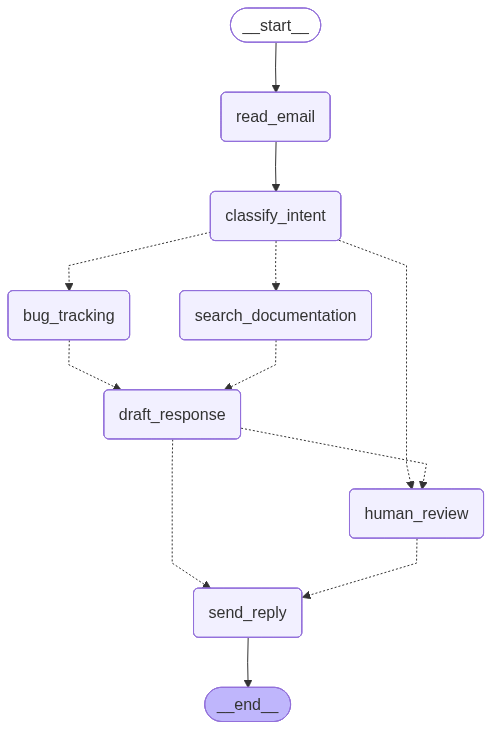

In [63]:
email_graph_builder = StateGraph(EmailAgentState)

email_graph_builder.add_node("read_email", read_email)
email_graph_builder.add_node("classify_intent", classify_intent)
email_graph_builder.add_node("search_documentation", search_documentation)
email_graph_builder.add_node("bug_tracking", bug_tracking)
email_graph_builder.add_node("human_review", human_review)
email_graph_builder.add_node("draft_response", draft_response)
email_graph_builder.add_node("send_reply", send_reply)

email_graph_builder.add_edge(START, "read_email")
email_graph_builder.add_edge("read_email", "classify_intent")
email_graph_builder.add_edge("send_reply", END)

email_graph = email_graph_builder.compile()
email_graph

## 11. 运行普通产品问题

这个输入会走：

```text
read_email -> classify_intent -> search_documentation -> draft_response -> send_reply
```

In [64]:
def initial_email_state(content: str, sender: str = "user@example.com") -> EmailAgentState:
    return {
        "email_content": content,
        "sender_email": sender,
        "classification": None,
        "search_results": [],
        "ticket_id": "",
        "draft_response": "",
        "final_action": "",
        "trace": [],
    }


question_result = email_graph.invoke(
    initial_email_state("I need help resetting my password.")
)

print("trace:", " -> ".join(question_result["trace"]))
print("classification:", question_result["classification"])
print("draft_response:", question_result["draft_response"])
print("final_action:", question_result["final_action"])

trace: read_email -> classify_intent:search_documentation -> search_documentation -> draft_response:send_reply -> send_reply
classification: {'intent': 'product_question', 'urgency': 'low', 'topic': 'how_to', 'summary': '用户咨询产品使用问题，可以先查文档。'}
draft_response: 根据帮助文档，你可以按以下方式处理：帮助文档：可以在账户设置中重置密码。；帮助文档：如无法登录，请先检查邮箱验证码。
final_action: reply_ready


## 12. 运行 bug 报告

这个输入会走：

```text
read_email -> classify_intent -> bug_tracking -> draft_response -> human_review -> send_reply
```

In [65]:
bug_result = email_graph.invoke(
    initial_email_state("The product crashes with a 500 error when I upload a file.")
)

print("trace:", " -> ".join(bug_result["trace"]))
print("classification:", bug_result["classification"])
print("ticket_id:", bug_result["ticket_id"])
print("draft_response:", bug_result["draft_response"])
print("final_action:", bug_result["final_action"])

trace: read_email -> classify_intent:bug_tracking -> bug_tracking -> draft_response:human_review -> human_review -> send_reply
classification: {'intent': 'bug_report', 'urgency': 'high', 'topic': 'product_error', 'summary': '用户报告产品错误，需要进入 bug 流程。'}
ticket_id: BUG-2026-0604-001
draft_response: 该邮件涉及高风险账单或高优先级问题，已转人工审核。
final_action: human_review_required


## 13. 运行账单问题

这个输入会直接进入 human review：

```text
read_email -> classify_intent -> human_review -> send_reply
```

In [66]:
billing_result = email_graph.invoke(
    initial_email_state("I was charged twice on my invoice.")
)

print("trace:", " -> ".join(billing_result["trace"]))
print("classification:", billing_result["classification"])
print("draft_response:", billing_result["draft_response"])
print("final_action:", billing_result["final_action"])

trace: read_email -> classify_intent:human_review -> human_review -> send_reply
classification: {'intent': 'billing_issue', 'urgency': 'critical', 'topic': 'billing', 'summary': '用户反馈账单或扣费问题，需要人工审核。'}
draft_response: 该邮件涉及高风险账单或高优先级问题，已转人工审核。
final_action: human_review_required


## 14. 和 Harness 的对应关系

| Thinking in LangGraph | 本仓库 Harness |
| --- | --- |
| state 只保存关键数据 | run / ledger / completed_steps |
| classify node | planner action |
| data node | repo/search/read 或业务查询 tool |
| action node | ToolDefinition 执行层 |
| human input node | approval_required / resume_approval |
| Command goto | action route / delegate role |

核心思想一致：

```text
不要让模型独自持有流程。
系统要把状态、边界、审批和验证显式表达出来。
```

## 15. 本讲练习

请为下面场景设计 LangGraph 节点：

```text
用户上传报销单，系统需要识别票据、校验金额、检查审批权限、需要时人工审核，最后生成入账结果。
```

要求写出：

1. state 里保存哪些字段
2. 至少 5 个 node
3. 哪些 node 是 LLM node
4. 哪些 node 是 action node
5. 哪些地方需要 human input node

## 16. 本讲小结

这一讲的核心：

```text
Thinking in LangGraph = 先设计状态和流程，再决定哪里使用模型。
```

你现在应该能判断：

- 如何把业务流程拆成节点
- 如何给节点分类
- 为什么 state 不应该塞满推理过程
- `Command(update=..., goto=...)` 如何表达动态路由
- human review 应该作为显式节点，而不是一句提示词

下一讲可以继续学习 LangGraph State 和 Reducer。